Задание 1: Анализ влияния размера тестовой выборки
Создайте цикл, который обучает логистическую регрессию при разных размерах тестовой выборки (от 0.1 до 0.5 с шагом 0.1). Постройте график зависимости точности на тесте от размера выборки. Объясните, почему при очень малом размере теста оценка качества становится нестабильной. Подсказка: используйте stratify=y для сохранения баланса классов.

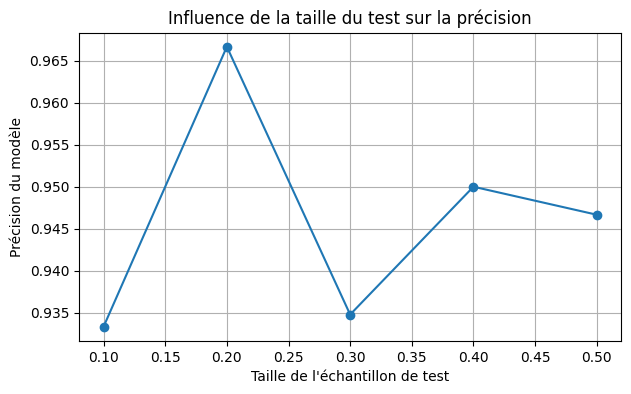

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Chargement des données
X, y = load_iris(return_X_y=True)

test_sizes = np.arange(0.1, 0.6, 0.1)
accuracies = []

for ts in test_sizes:
    # stratify=y pour garder l'équilibre des classes
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ts, stratify=y, random_state=42
    )

    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Affichage
plt.figure(figsize=(7,4))
plt.plot(test_sizes, accuracies, marker='o')
plt.xlabel("Taille de l'échantillon de test")
plt.ylabel("Précision du modèle")
plt.title("Influence de la taille du test sur la précision")
plt.grid(True)
plt.show()


Задание 2: Диагностика мультиколлинеарности
На датасете California Housing (fetch_california_housing) постройте корреляционную матрицу. Найдите пару признаков с корреляцией > 0.9. Объясните, как мультиколлинеарность влияет на интерпретацию коэффициентов линейной регрессии. Подсказка: используйте np.abs(corr) > 0.9 для фильтрации.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Chargement des données
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Matrice de corrélation
corr = df.corr()

# Filtrer les corrélations > 0.9
high_corr = np.abs(corr) > 0.9

# Affichage des paires fortement corrélées
print("Paires de variables avec corrélation > 0.9 :")
for col in corr.columns:
    for row in corr.index:
        if row != col and high_corr.loc[row, col]:
            print(f"{row} ↔ {col} : corr = {corr.loc[row, col]:.3f}")


Paires de variables avec corrélation > 0.9 :
Longitude ↔ Latitude : corr = -0.925
Latitude ↔ Longitude : corr = -0.925


Для датасета Iris постройте график зависимости точности от параметра k (от 1 до 30). Найдите оптимальное k через кросс-валидацию. Объясните, почему при k=1 наблюдается переобучение, а при очень больших k — недообучение. Подсказка: используйте cross_val_score с cv=5.

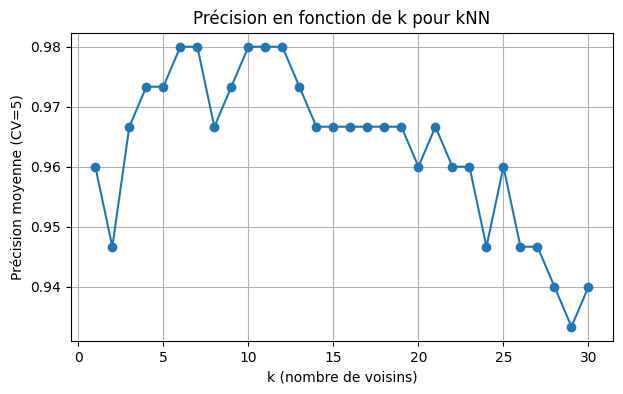

k optimal : 6


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Chargement des données
X, y = load_iris(return_X_y=True)

k_values = range(1, 31)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5)
    accuracies.append(scores.mean())

# Affichage
plt.figure(figsize=(7,4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k (nombre de voisins)")
plt.ylabel("Précision moyenne (CV=5)")
plt.title("Précision en fonction de k pour kNN")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print("k optimal :", best_k)
